# **1. Perkenalan Dataset**

## Dataset: Telco Customer Churn

Dataset **Telco Customer Churn** dari IBM/Watson merupakan dataset publik yang
berisi informasi pelanggan layanan telekomunikasi beserta status churn-nya.

### Informasi Dataset
| Atribut          | Keterangan                                      |
|------------------|-------------------------------------------------|
| **Sumber**       | IBM/telco-customer-churn-on-icp4d (GitHub)     |
| **Jumlah Baris** | 7.043 baris                                     |
| **Jumlah Kolom** | 21 kolom (20 fitur + 1 target)                 |
| **Target**       | `Churn` – apakah pelanggan berhenti berlangganan|
| **Tipe Task**    | Klasifikasi Biner (Yes / No)                   |
| **Format**       | CSV                                             |

### Fitur Utama
- **Demografis**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Layanan**: `PhoneService`, `MultipleLines`, `InternetService`, `StreamingTV`, dst.
- **Akun**: `tenure`, `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`

### Tujuan Eksperimen
Melakukan eksplorasi dan preprocessing dataset secara menyeluruh sebagai fondasi
sebelum melatih model machine learning pada tahap berikutnya.

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh library Python yang dibutuhkan untuk
analisis data dan pembangunan model machine learning.

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Konfigurasi tampilan
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✓ Semua library berhasil diimpor!")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✓ Semua library berhasil diimpor!
  pandas  : 2.2.2
  numpy   : 2.0.2


# **3. Memuat Dataset**

Dataset dimuat langsung dari URL GitHub IBM tanpa perlu login.  
URL: `https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`

In [2]:
# ============================================================
# 3a. LOAD DATASET
# ============================================================
DATASET_URL = (
    'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
    '/master/data/Telco-Customer-Churn.csv'
)

# Muat dataset
df = pd.read_csv(DATASET_URL)

print(f"✓ Dataset berhasil dimuat!")
print(f"  Shape: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"\nLima baris pertama:")
df.head()

✓ Dataset berhasil dimuat!
  Shape: 7,043 baris × 21 kolom

Lima baris pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [3]:
# ============================================================
# 3b. INFORMASI DASAR DATASET
# ============================================================
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"\nShape   : {df.shape}")
print(f"Kolom   : {list(df.columns)}")

print("\n--- INFO ---")
df.info()

print("\n--- JUMLAH NILAI UNIK PER KOLOM ---")
unique_df = pd.DataFrame({
    'Tipe Data'    : df.dtypes,
    'Nilai Unik'   : df.nunique(),
    'Contoh Nilai' : [df[c].unique()[:3] for c in df.columns]
})
display(unique_df)

INFORMASI DATASET

Shape   : (7043, 21)
Kolom   : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-nul

,Tipe Data,Nilai Unik,Contoh Nilai
customerID,object,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK]"
gender,object,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,object,2,"[Yes, No]"
Dependents,object,2,"[No, Yes]"
tenure,int64,73,"[1, 34, 2]"
PhoneService,object,2,"[No, Yes]"
MultipleLines,object,3,"[No phone service, No, Yes]"
InternetService,object,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,3,"[No, Yes, No internet service]"


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita akan memahami karakteristik dataset secara mendalam
melalui statistik deskriptif, pengecekan kualitas data, dan visualisasi.

In [4]:
# ============================================================
# 4a. STATISTIK DESKRIPTIF
# ============================================================
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)

print("\n--- Statistik Fitur Numerik ---")
display(df.describe())

print("\n--- Distribusi Target Variable: Churn ---")
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
churn_summary = pd.DataFrame({
    'Jumlah'     : churn_counts,
    'Persentase' : churn_pct.round(2).astype(str) + '%'
})
display(churn_summary)

STATISTIK DESKRIPTIF

--- Statistik Fitur Numerik ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.0000,7043.0000,7043.0000
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500



--- Distribusi Target Variable: Churn ---


,Jumlah,Persentase
Churn,,
No,5174,73.46%
Yes,1869,26.54%


ANALISIS MISSING VALUES

[INFO] 'TotalCharges' dikonversi ke numerik untuk keperluan analisis EDA.
       String kosong (spasi) menjadi NaN.

Kolom dengan missing values:


,Jumlah Missing,Persentase (%)
TotalCharges,11,0.1600



→ Setelah konversi: 'TotalCharges' memiliki 11 NaN


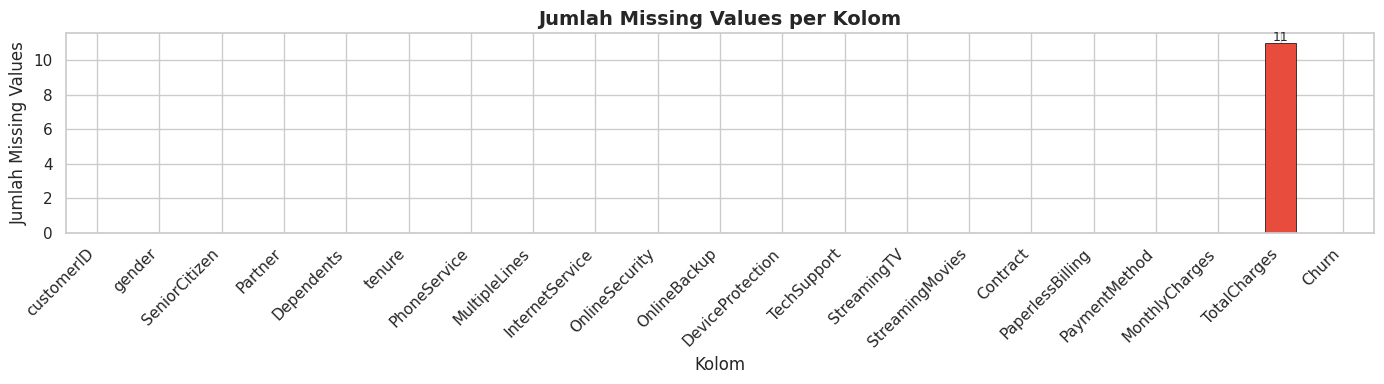

In [5]:
# ============================================================
# 4b. CEK MISSING VALUES
# ============================================================
print("=" * 60)
print("ANALISIS MISSING VALUES")
print("=" * 60)

# Konversi TotalCharges untuk analisis EDA saja
# (kolom ini bertipe object karena ada spasi untuk pelanggan tenure=0)
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

print("\n[INFO] 'TotalCharges' dikonversi ke numerik untuk keperluan analisis EDA.")
print("       String kosong (spasi) menjadi NaN.")

# Hitung missing values
mv_count = df_eda.isnull().sum()
mv_pct   = (df_eda.isnull().sum() / len(df_eda) * 100).round(2)
mv_df = pd.DataFrame({
    'Jumlah Missing'  : mv_count,
    'Persentase (%)'  : mv_pct
})

mv_nonzero = mv_df[mv_df['Jumlah Missing'] > 0]
print(f"\nKolom dengan missing values:")
if len(mv_nonzero) > 0:
    display(mv_nonzero)
else:
    print("  Tidak ada (sebelum konversi TotalCharges)")
print(f"\n→ Setelah konversi: 'TotalCharges' memiliki "
      f"{df_eda['TotalCharges'].isnull().sum()} NaN")

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in df_eda.isnull().sum()]
df_eda.isnull().sum().plot(kind='bar', ax=ax, color=colors, edgecolor='black', lw=0.5)
ax.set_title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing Values')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for patch in ax.patches:
    if patch.get_height() > 0:
        ax.text(patch.get_x() + patch.get_width()/2,
                patch.get_height() + 0.1,
                str(int(patch.get_height())),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 4c. CEK DATA DUPLIKAT
# ============================================================
print("=" * 60)
print("ANALISIS DATA DUPLIKAT")
print("=" * 60)

n_duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat : {n_duplikat}")
print(f"Total baris           : {len(df):,}")
print(f"Persentase            : {n_duplikat/len(df)*100:.4f}%")

if n_duplikat > 0:
    print("\nContoh baris duplikat:")
    display(df[df.duplicated(keep=False)].head(6))
else:
    print("\n✓ Tidak ada data duplikat dalam dataset.")

ANALISIS DATA DUPLIKAT

Jumlah baris duplikat : 0
Total baris           : 7,043
Persentase            : 0.0000%

✓ Tidak ada data duplikat dalam dataset.


DISTRIBUSI TARGET: Churn


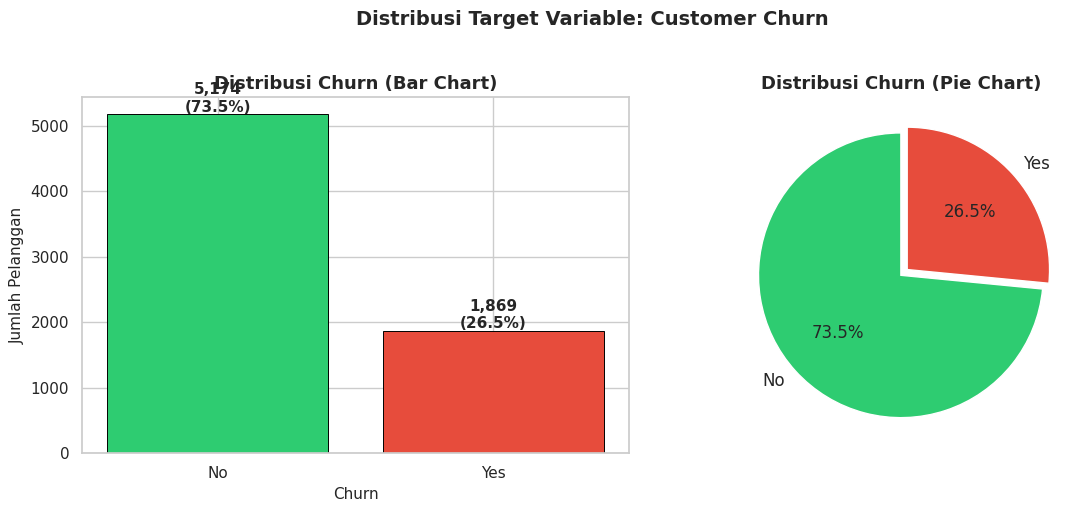


Total pelanggan : 7,043
  No     : 5,174  (73.5%)
  Yes    : 1,869  (26.5%)

⚠️  Class imbalance: ~73.5% No vs ~26.5% Yes
   → Gunakan stratify=y saat split untuk menjaga proporsi


In [7]:
# ============================================================
# 4d. DISTRIBUSI TARGET VARIABLE
# ============================================================
print("=" * 60)
print("DISTRIBUSI TARGET: Churn")
print("=" * 60)

churn_counts = df['Churn'].value_counts()
colors = ['#2ECC71', '#E74C3C']    # hijau = No, merah = Yes

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar Chart ---
bars = axes[0].bar(
    churn_counts.index, churn_counts.values,
    color=colors, edgecolor='black', linewidth=0.7
)
axes[0].set_title('Distribusi Churn (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2, h + 40,
        f'{int(h):,}\n({h/len(df)*100:.1f}%)',
        ha='center', fontsize=11, fontweight='bold'
    )

# --- Pie Chart ---
axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.06),
    textprops={'fontsize': 12}
)
axes[1].set_title('Distribusi Churn (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target Variable: Customer Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal pelanggan : {len(df):,}")
for k, v in churn_counts.items():
    print(f"  {k:5s}  : {v:,}  ({v/len(df)*100:.1f}%)")
print("\n⚠️  Class imbalance: ~73.5% No vs ~26.5% Yes")
print("   → Gunakan stratify=y saat split untuk menjaga proporsi")

DISTRIBUSI FITUR NUMERIK


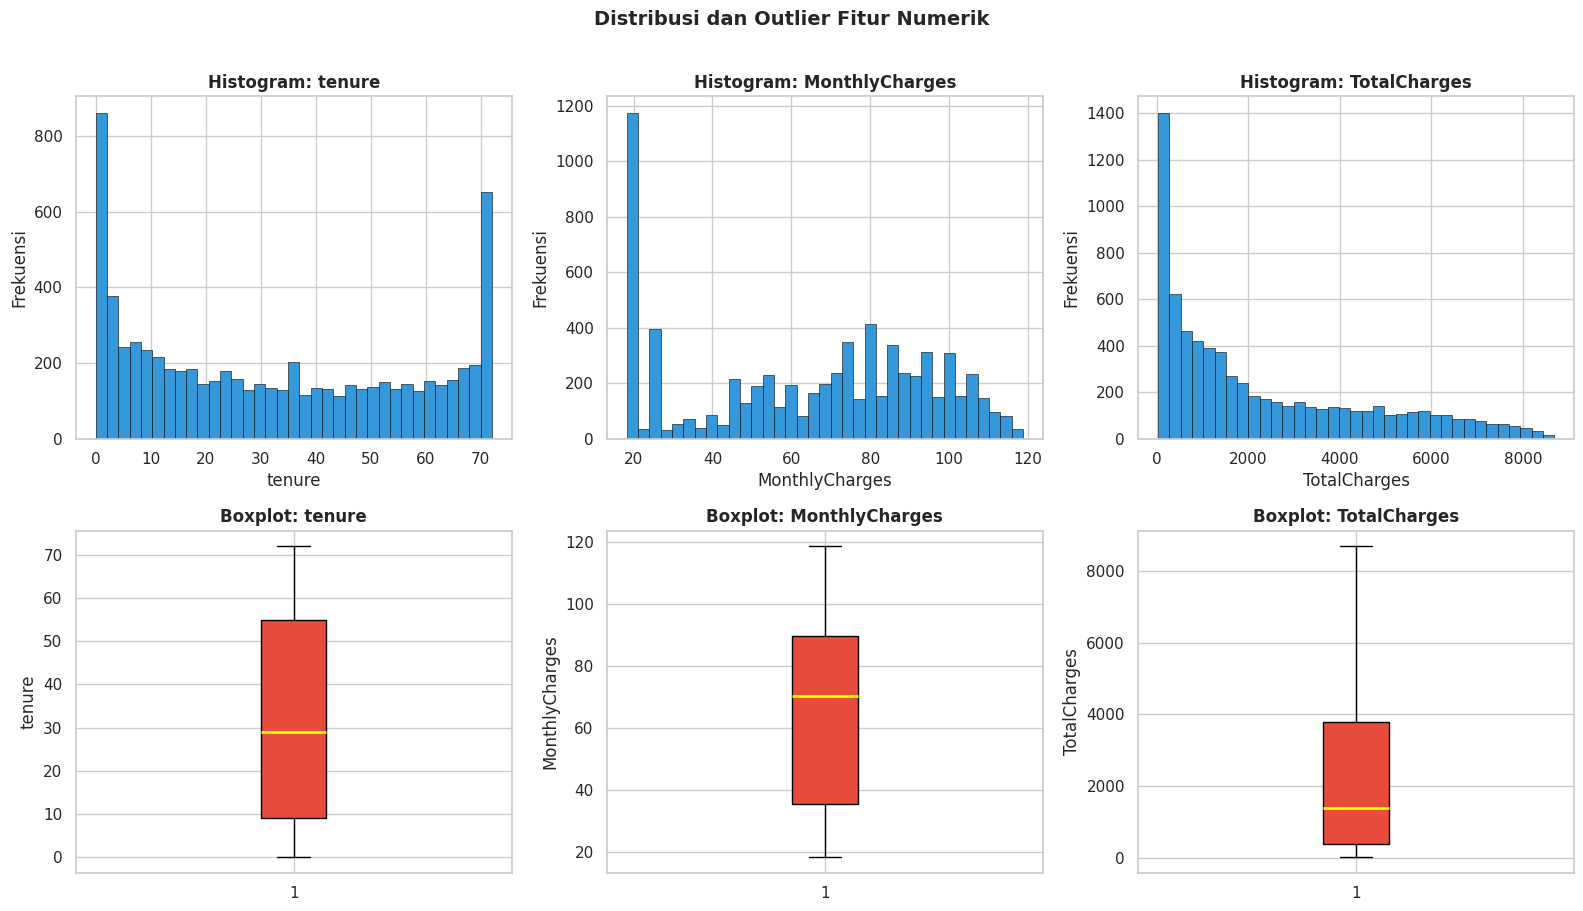


Statistik ringkas fitur numerik:


,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3711,64.7617,2283.3004
std,24.5595,30.0900,2266.7714
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4750
75%,55.0000,89.8500,3794.7375
max,72.0000,118.7500,8684.8000


In [8]:
# ============================================================
# 4e. DISTRIBUSI FITUR NUMERIK
# ============================================================
print("=" * 60)
print("DISTRIBUSI FITUR NUMERIK")
print("=" * 60)

df_num = df_eda.copy()   # sudah ada TotalCharges sebagai float
numeric_feats = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(numeric_feats):
    data = df_num[col].dropna()

    # Histogram
    axes[0, i].hist(data, bins=35, color='#3498DB', edgecolor='black', linewidth=0.4)
    axes[0, i].set_title(f'Histogram: {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot
    bp = axes[1, i].boxplot(
        data, patch_artist=True, vert=True,
        boxprops=dict(facecolor='#E74C3C', color='black'),
        medianprops=dict(color='yellow', linewidth=2),
        flierprops=dict(marker='o', color='gray', markersize=3)
    )
    axes[1, i].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribusi dan Outlier Fitur Numerik',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nStatistik ringkas fitur numerik:")
display(df_num[numeric_feats].describe())

HEATMAP KORELASI


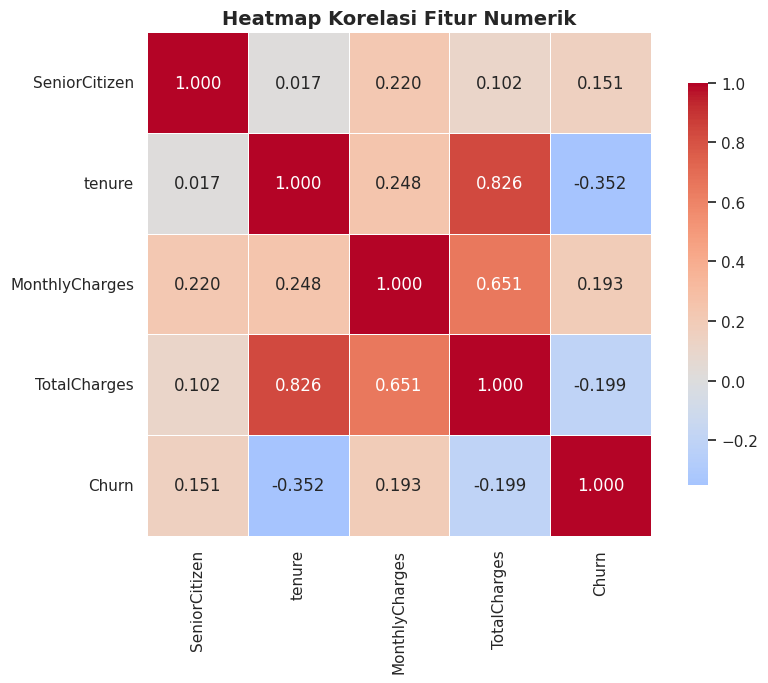


Korelasi dengan Target (Churn):
Churn             1.0000
MonthlyCharges    0.1934
SeniorCitizen     0.1509
TotalCharges     -0.1995
tenure           -0.3522


In [9]:
# ============================================================
# 4f. HEATMAP KORELASI
# ============================================================
print("=" * 60)
print("HEATMAP KORELASI")
print("=" * 60)

df_corr = df_eda.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numeric_for_corr = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_corr[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi dengan Target (Churn):")
print(corr_matrix['Churn'].sort_values(ascending=False).to_string())

ANALISIS FITUR KATEGORIKAL VS CHURN


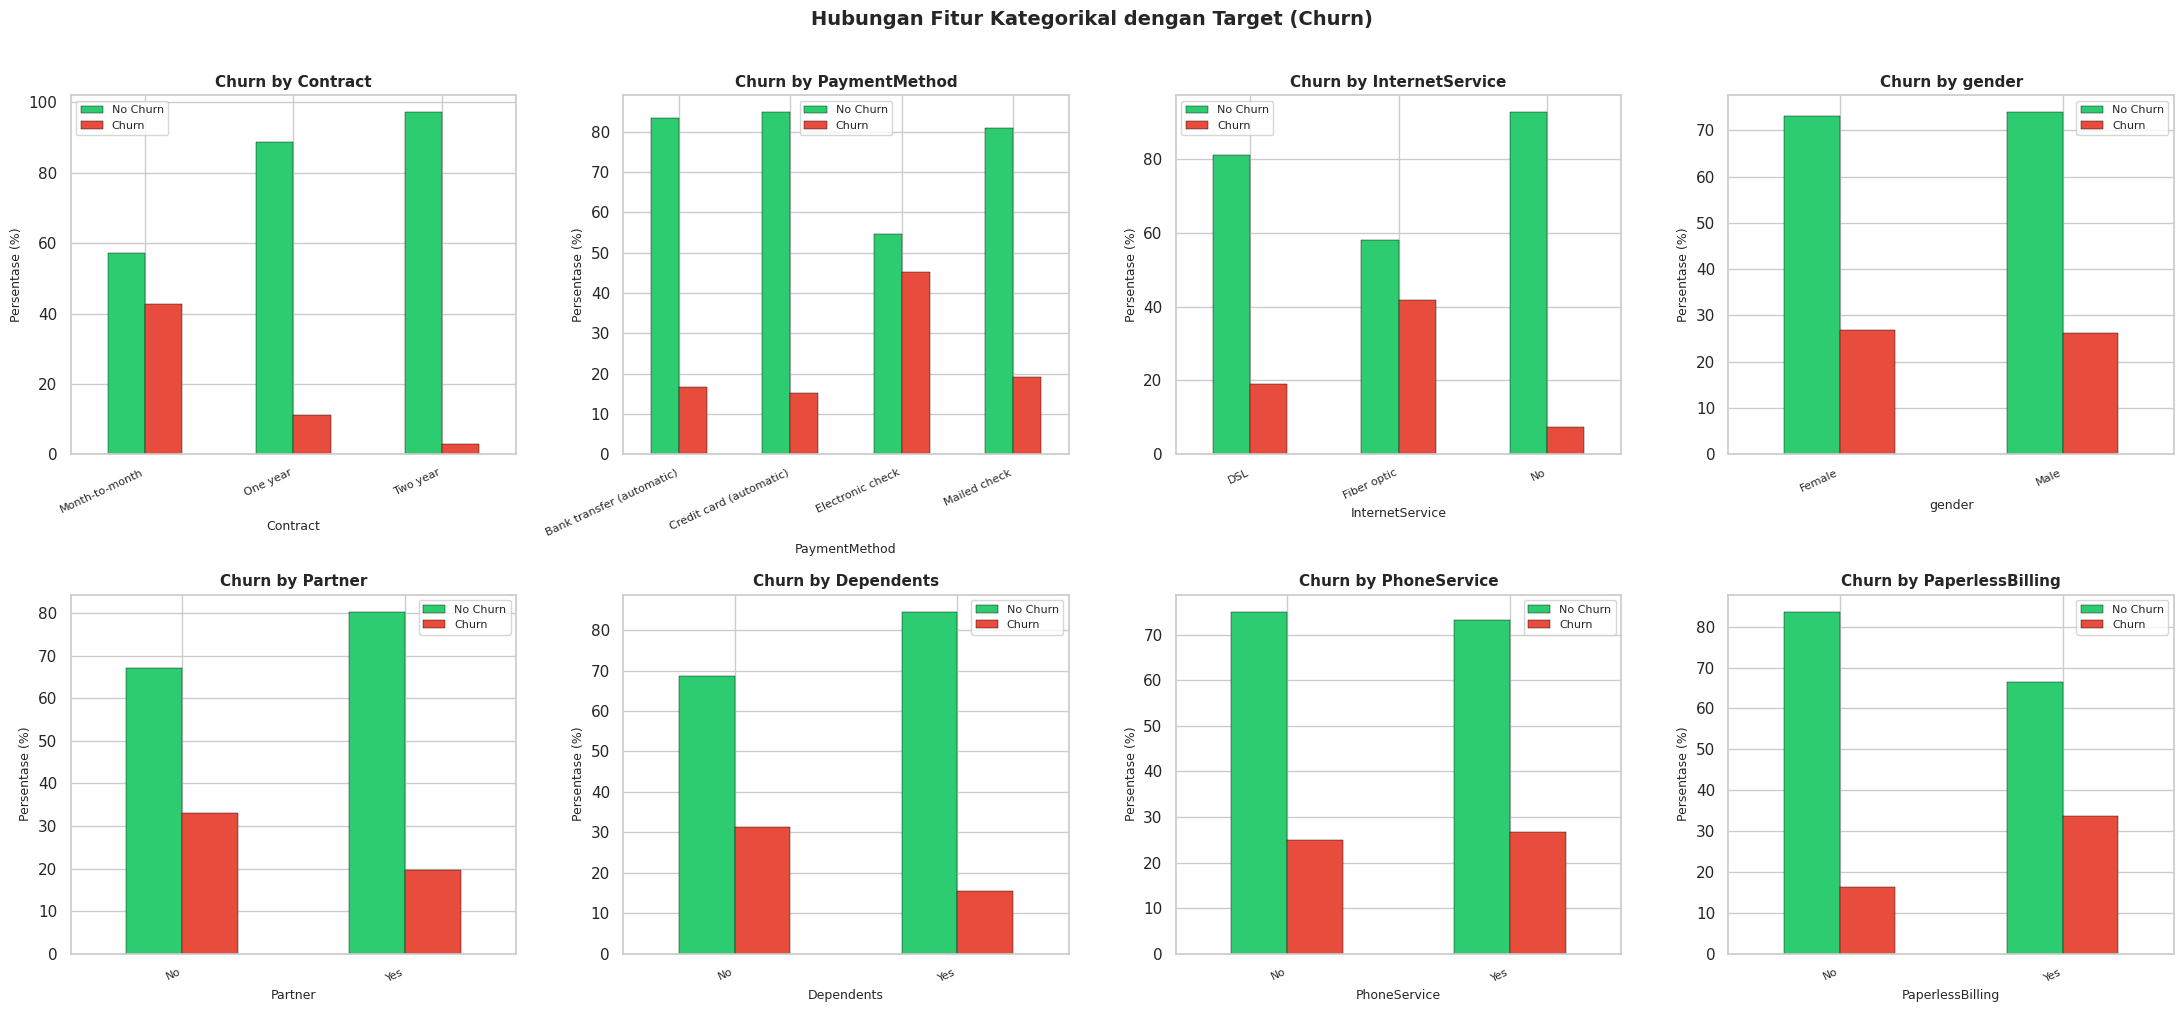

In [10]:
# ============================================================
# 4g. ANALISIS FITUR KATEGORIKAL
# ============================================================
print("=" * 60)
print("ANALISIS FITUR KATEGORIKAL VS CHURN")
print("=" * 60)

cat_to_plot = [
    'Contract', 'PaymentMethod', 'InternetService',
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for i, col in enumerate(cat_to_plot):
    ct = (
        df.groupby(col)['Churn']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )
    ct.plot(
        kind='bar', ax=axes_flat[i],
        color=['#2ECC71', '#E74C3C'],
        edgecolor='black', linewidth=0.3
    )
    axes_flat[i].set_title(f'Churn by {col}', fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel(col, fontsize=9)
    axes_flat[i].set_ylabel('Persentase (%)', fontsize=9)
    axes_flat[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes_flat[i].set_xticklabels(
        axes_flat[i].get_xticklabels(), rotation=25, ha='right', fontsize=8
    )

plt.suptitle(
    'Hubungan Fitur Kategorikal dengan Target (Churn)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 📊 Ringkasan Temuan EDA

### 🔍 Temuan 1: Class Imbalance pada Target Variable
Dataset menunjukkan ketidakseimbangan kelas:
- **Tidak Churn (No)**: ~73.5% (5.174 pelanggan)
- **Churn (Yes)**: ~26.5% (1.869 pelanggan)

**Implikasi Preprocessing**: Gunakan `stratify=y` pada `train_test_split` agar
distribusi kelas tetap proporsional di kedua set data.

### 🔍 Temuan 2: Missing Values pada TotalCharges
Kolom `TotalCharges` bertipe `object` karena mengandung string spasi untuk
pelanggan baru (tenure = 0). Setelah konversi ke numerik, terdapat **11 baris NaN**.

**Implikasi Preprocessing**: Imputasi dengan **median** (aman terhadap outlier,
jumlahnya hanya ~0.16% dari total data).

### 🔍 Temuan 3: Faktor Signifikan Penyebab Churn
- **tenure**: Korelasi negatif dengan Churn — pelanggan lama lebih setia.
- **Contract**: Pelanggan *Month-to-month* jauh lebih cenderung churn dibanding
  pelanggan dengan kontrak tahunan atau dua tahunan.
- **MonthlyCharges**: Korelasi positif — tagihan bulanan tinggi → risiko churn
  lebih besar.
- **InternetService**: Pelanggan *Fiber Optic* memiliki churn rate tertinggi.

**Implikasi Preprocessing**: Semua fitur dipertahankan. Fitur numerik perlu
distandarisasi. Fitur kategorikal perlu di-encode sebelum digunakan.

# **5. Data Preprocessing**

Berdasarkan temuan EDA, berikut tahapan preprocessing yang akan dilakukan:
1. Hapus kolom `customerID` (bukan fitur prediktif)
2. Konversi `TotalCharges` ke tipe numerik
3. Imputasi missing values dengan median
4. Hapus data duplikat
5. Encode fitur kategorikal dengan `LabelEncoder`
6. Pisahkan fitur (X) dan target (y)
7. Split data: 80% training, 20% testing (stratified)
8. Standarisasi fitur numerik dengan `StandardScaler`
9. Simpan hasil preprocessing ke file CSV

In [11]:
# ============================================================
# INISIALISASI – salin dataframe original sebelum preprocessing
# ============================================================
df_clean = df.copy()
print(f"Shape awal sebelum preprocessing: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")

Shape awal sebelum preprocessing: (7043, 21)
Kolom: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
# ============================================================
# 5a. HANDLING MISSING VALUES
# ============================================================
print("=" * 60)
print("STEP 5a: HANDLING MISSING VALUES")
print("=" * 60)

# --- 1: Hapus kolom customerID (identifier, bukan fitur prediktif) ---
df_clean = df_clean.drop('customerID', axis=1)
print(f"[1] ✓ Kolom 'customerID' dihapus  → shape: {df_clean.shape}")

# --- 2: Konversi TotalCharges ke float ---
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
n_nan = df_clean['TotalCharges'].isnull().sum()
print(f"[2] ✓ 'TotalCharges' → float  ({n_nan} NaN ditemukan)")

# --- 3: Imputasi NaN TotalCharges dengan median ---
median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_tc, inplace=True)
print(f"[3] ✓ NaN diimputasi dengan median = {median_tc:.4f}")

# --- Verifikasi ---
total_mv = df_clean.isnull().sum().sum()
print(f"\n✓ Verifikasi – Total missing values tersisa: {total_mv}")
display(df_clean.isnull().sum().to_frame('Missing Values'))

STEP 5a: HANDLING MISSING VALUES
[1] ✓ Kolom 'customerID' dihapus  → shape: (7043, 20)
[2] ✓ 'TotalCharges' → float  (11 NaN ditemukan)
[3] ✓ NaN diimputasi dengan median = 1397.4750

✓ Verifikasi – Total missing values tersisa: 0


,Missing Values
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [13]:
# ============================================================
# 5b. HANDLING DATA DUPLIKAT
# ============================================================
print("=" * 60)
print("STEP 5b: HANDLING DATA DUPLIKAT")
print("=" * 60)

n_dup_sebelum = df_clean.duplicated().sum()
print(f"Duplikat sebelum : {n_dup_sebelum}")

df_clean = df_clean.drop_duplicates()

n_dup_sesudah = df_clean.duplicated().sum()
print(f"Duplikat sesudah : {n_dup_sesudah}")
print(f"✓ Shape setelah drop duplikat: {df_clean.shape}")

STEP 5b: HANDLING DATA DUPLIKAT
Duplikat sebelum : 22
Duplikat sesudah : 0
✓ Shape setelah drop duplikat: (7021, 20)


In [14]:
# ============================================================
# 5c. ENCODING FITUR KATEGORIKAL
# ============================================================
print("=" * 60)
print("STEP 5c: ENCODING FITUR KATEGORIKAL")
print("=" * 60)

# --- Encode target variable terlebih dahulu ---
# (No → 0, Yes → 1)  – urutan alfabetis LabelEncoder sudah benar
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
print(f"✓ Target 'Churn' encoded: No→0, Yes→1")
print(f"  Distribusi: {dict(df_clean['Churn'].value_counts().sort_index())}")

# --- LabelEncode semua kolom bertipe object (fitur kategorikal) ---
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"\nKolom kategorikal yang akan di-encode ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}: {sorted(df_clean[col].unique())[:4]}...")

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le
    print(f"✓ LabelEncoded: {col}")

print(f"\nShape setelah encoding: {df_clean.shape}")
print("\nLima baris pertama setelah encoding:")
display(df_clean.head())

STEP 5c: ENCODING FITUR KATEGORIKAL
✓ Target 'Churn' encoded: No→0, Yes→1
  Distribusi: {0: np.int64(5164), 1: np.int64(1857)}

Kolom kategorikal yang akan di-encode (15):
  - gender: ['Female', 'Male']...
  - Partner: ['No', 'Yes']...
  - Dependents: ['No', 'Yes']...
  - PhoneService: ['No', 'Yes']...
  - MultipleLines: ['No', 'No phone service', 'Yes']...
  - InternetService: ['DSL', 'Fiber optic', 'No']...
  - OnlineSecurity: ['No', 'No internet service', 'Yes']...
  - OnlineBackup: ['No', 'No internet service', 'Yes']...
  - DeviceProtection: ['No', 'No internet service', 'Yes']...
  - TechSupport: ['No', 'No internet service', 'Yes']...
  - StreamingTV: ['No', 'No internet service', 'Yes']...
  - StreamingMovies: ['No', 'No internet service', 'Yes']...
  - Contract: ['Month-to-month', 'One year', 'Two year']...
  - PaperlessBilling: ['No', 'Yes']...
  - PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']...
✓ LabelEncoded: ge

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.8500,29.8500,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.9500,1889.5000,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.8500,108.1500,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.3000,1840.7500,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.7000,151.6500,1


In [15]:
# ============================================================
# 5d. PEMISAHAN FITUR DAN TARGET
# ============================================================
print("=" * 60)
print("STEP 5d: PEMISAHAN FITUR DAN TARGET")
print("=" * 60)

TARGET = 'Churn'
X = df_clean.drop(TARGET, axis=1)
y = df_clean[TARGET]

print(f"Target variable : {TARGET}")
print(f"Shape X (fitur) : {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nKolom fitur ({X.shape[1]}):")
print(list(X.columns))
print(f"\nDistribusi y:")
print(y.value_counts().rename({0: 'No (0)', 1: 'Yes (1)'}))

STEP 5d: PEMISAHAN FITUR DAN TARGET
Target variable : Churn
Shape X (fitur) : (7021, 19)
Shape y (target): (7021,)

Kolom fitur (19):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Distribusi y:
Churn
No (0)     5164
Yes (1)    1857
Name: count, dtype: int64


In [16]:
# ============================================================
# 5e-5f. SPLIT TRAIN-TEST + NORMALISASI
#
# CATATAN: Split dilakukan SEBELUM normalisasi agar StandardScaler
#          di-fit hanya pada data training → menghindari data leakage.
# ============================================================
print("=" * 60)
print("STEP 5e: SPLIT TRAIN-TEST (80:20, stratified)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Menjaga proporsi kelas tetap seimbang
)

print(f"X_train : {X_train.shape}   |  y_train: {y_train.shape}")
print(f"X_test  : {X_test.shape}    |  y_test : {y_test.shape}")
print(f"\nDistribusi y_train: {dict(y_train.value_counts().sort_index())}")
print(f"Distribusi y_test : {dict(y_test.value_counts().sort_index())}")

print("\n" + "=" * 60)
print("STEP 5f: NORMALISASI / STANDARISASI (StandardScaler)")
print("=" * 60)

NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f"\nFitur yang distandardisasi: {NUMERIC_FEATURES}")
print(f"\nSebelum standardisasi (mean / std X_train):")
display(X_train[NUMERIC_FEATURES].describe().loc[['mean', 'std']])

# Fit HANYA pada X_train, transform pada keduanya
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

print(f"\nSetelah standardisasi (mean / std X_train):")
display(X_train[NUMERIC_FEATURES].describe().loc[['mean', 'std']])
print(f"\n✓ StandardScaler fit only on training set → tidak ada data leakage")

STEP 5e: SPLIT TRAIN-TEST (80:20, stratified)
X_train : (5616, 19)   |  y_train: (5616,)
X_test  : (1405, 19)    |  y_test : (1405,)

Distribusi y_train: {0: np.int64(4131), 1: np.int64(1485)}
Distribusi y_test : {0: np.int64(1033), 1: np.int64(372)}

STEP 5f: NORMALISASI / STANDARISASI (StandardScaler)

Fitur yang distandardisasi: ['tenure', 'MonthlyCharges', 'TotalCharges']

Sebelum standardisasi (mean / std X_train):


,tenure,MonthlyCharges,TotalCharges
mean,32.4332,64.8947,2292.5628
std,24.5188,30.0561,2274.0561



Setelah standardisasi (mean / std X_train):


,tenure,MonthlyCharges,TotalCharges
mean,0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001



✓ StandardScaler fit only on training set → tidak ada data leakage


In [17]:
# ============================================================
# 5g. SIMPAN HASIL PREPROCESSING
# ============================================================
print("=" * 60)
print("STEP 5g: SIMPAN HASIL PREPROCESSING")
print("=" * 60)

OUTPUT_FOLDER = 'telco_churn_preprocessing'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Simpan ke CSV
X_train.to_csv(f'{OUTPUT_FOLDER}/X_train.csv', index=False)
X_test.to_csv(f'{OUTPUT_FOLDER}/X_test.csv',   index=False)
y_train.to_csv(f'{OUTPUT_FOLDER}/y_train.csv', index=False)
y_test.to_csv(f'{OUTPUT_FOLDER}/y_test.csv',   index=False)

print(f"✓ Folder '{OUTPUT_FOLDER}/' dibuat")
print(f"\nFile yang disimpan:")
for fname in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']:
    fpath = f'{OUTPUT_FOLDER}/{fname}'
    print(f"  {fpath}")

print(f"\nRingkasan output:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"\n✓ Preprocessing selesai! Data siap digunakan untuk pelatihan model.")

# Tampilkan preview hasil
print("\nPreview X_train (5 baris pertama):")
display(X_train.head())

STEP 5g: SIMPAN HASIL PREPROCESSING
✓ Folder 'telco_churn_preprocessing/' dibuat

File yang disimpan:
  telco_churn_preprocessing/X_train.csv
  telco_churn_preprocessing/X_test.csv
  telco_churn_preprocessing/y_train.csv
  telco_churn_preprocessing/y_test.csv

Ringkasan output:
  X_train : (5616, 19)
  X_test  : (1405, 19)
  y_train : (5616,)
  y_test  : (1405,)

✓ Preprocessing selesai! Data siap digunakan untuk pelatihan model.

Preview X_train (5 baris pertama):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2629,1,0,0,0,-1.2413,1,0,1,0,0,0,0,0,0,0,0,1,0.1932,-0.9464
2650,0,0,0,0,-0.7111,1,2,1,2,0,2,0,0,0,0,1,1,0.6474,-0.4353
1418,1,0,1,1,1.4099,1,2,1,0,2,0,0,0,2,0,1,0,0.8204,1.7945
5774,1,0,0,0,-1.1190,1,0,0,0,2,0,2,0,2,0,1,0,0.0235,-0.8587
2425,1,0,0,0,-0.2624,1,0,2,1,1,1,1,1,1,0,1,2,-1.4838,-0.7834
